# Depositional Systems: Progradation, Aggradation, and Retrogradation

This notebook is TracerDiff's main worked example. It runs the same model three
times with three different relative sea level histories (`sl_fun`) and
depth-growth functions (`growth_fun_alg`), producing three
sequence-stratigraphic stacking patterns:

- **Progradation** -- sediment supply outpaces accommodation; the shoreline
  steps seaward and beds stack laterally.
- **Aggradation** -- supply and accommodation are balanced on average, but
  cyclical relative sea-level (here, a repeating sawtooth) produces
  vertically-stacked parasequences bounded by flooding surfaces.
- **Retrogradation** -- accommodation outpaces supply (rising relative sea
  level); the shoreline steps landward and beds thin/backstep.

Everything here uses the *same* diffusion + tracer-advection physics
(`marine_K`, `land_K`, `smooth_K`, `A`) -- only the sea-level curve and the
growth-vs-depth function change between runs. 

Adapted from the `depositional_systems.ipynb` analysis notebook in
[Paleozoic_CIEs](https://github.com/VanWieren/Paleozoic_CIEs) (van Wieren et
al., 2026, EPSL, https://doi.org/10.1016/j.epsl.2025.119745), trimmed down and
re-commented as a standalone example. The same model has since also been used
in a second paper, van Wieren, Dyer & Husson, 2026, EPSL,
https://doi.org/10.1016/j.epsl.2026.120058 (analysis notebooks at
[shuram_TOC_public](https://github.com/VanWieren/shuram_TOC_public)).


## Imports

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
jax.config.update('jax_platform_name', 'cpu')
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from matplotlib.lines import Line2D
import seaborn as sns
import string

# pip install -e /path/to/TracerDiff  (see the TracerDiff README for full instructions)
from tracerdiff import run, Model_output
from tracerdiff.utils import *  # bosscher_G, sbar, and other small helpers used below


## Model setup

`params` holds everything `run()` needs that *doesn't* vary between the three
scenarios below: grid resolution/extent, time stepping, diffusivities
(`marine_K`/`land_K`/`smooth_K`), the mixed-layer depth `A`, and the
isotopic-offset/growth-coefficient defaults. See the TracerDiff README's
"Model parameters" table for what each key controls.

In [2]:
# from the current method
params = {'Nx':400,        # was 200; 400
          'xmin':0,
          'xmax':6000,     # was 180, scaled up, just need to change slope of hi
          'dx':0.8, #'none',     # 0.1 # if none defaults to (xmax-xmin)/(Nx); 0.8
          'start':0,
          'dt':0.1,
          'total_n':2000,
          'compiled_steps':100,
          'org_epsilon':0,   # ‰; matches shuram_TOC_public convention
          'pel_epsilon':0,   # ‰; 1.5
          'alg_epsilon':0,
          'coral_epsilon':0,
          'ocean_depth':0,  # depth at which seawater reflects open ocean
          'marine_K':2.5e-1,   # 1e-2; 1.5e-1
          'land_K':5e-1,   # 2e-2; 2.5e-1
          'smooth_K':6,      # was 10; the lower it is the more of a sharp step function it is
          'grid_ylen':1000,       # 10000; I really don't think it needs to be this big
          'base_depth':10,       # bottom n meters averaged for reaction-curve lower bound (matches shuram_TOC_public convention)
          'A':0.1}             # 0.01 0.1, I think needs to be smaller to scale with small magnitude of this run's topography changes
                             # A needs to be tuned. If A too big or too small, model provides unrealistic or incorrect functionality

# build time and space constraints for initial condition setting and initiation functions (sl, growth, etc.)
x,t,end = init_vars(params)

### Initial conditions and the growth-vs-depth function

`h` is the initial topography (a simple linear ramp), `wi_p`/`wi_m` are
candidate initial proxy (e.g. d13C) profiles, and `sec_w_fun` is the secular
("background") proxy curve the boundary condition follows over time.
`algal_growth` is a Bosscher & Schlager-style photosynthesis-limited growth
curve (`bosscher_G`) -- carbonate factory productivity as a function of water
depth -- which gets reused (with different steepness `k`) as `growth_fun_alg`
in each scenario below.

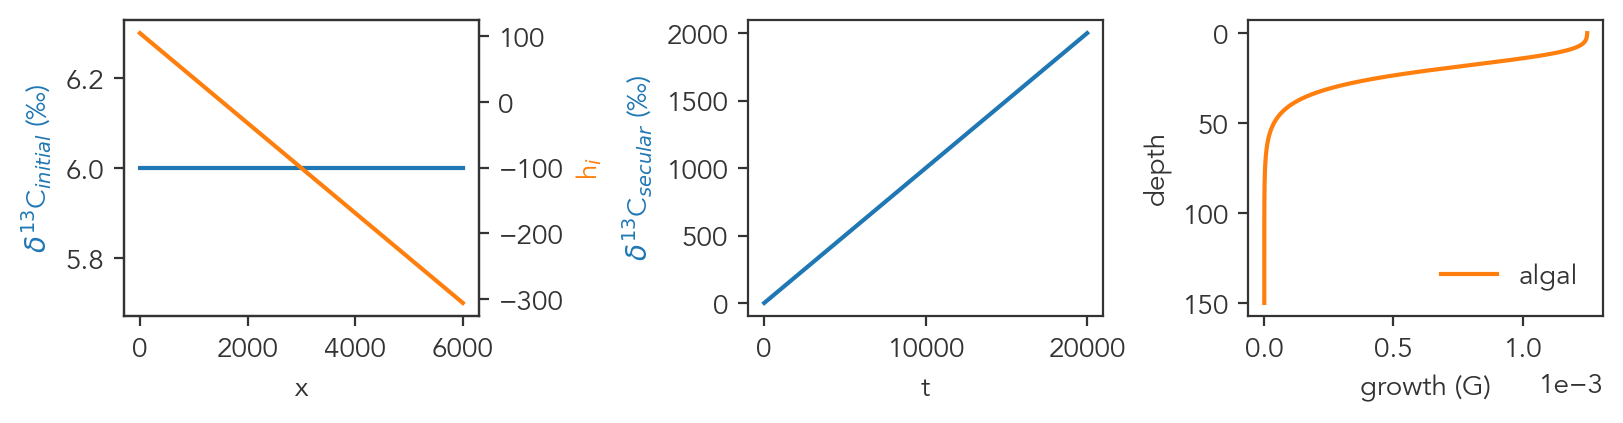

In [3]:
## Define h: initial topographic composition
h = -0.0685*x+105 # for xmax of 6000; slope chosen to match bahamas aspect ratio

## Define w: initial proxy composition
wi_p = jnp.ones_like(h)*6 # shallow value boundary condition for positive run

# secular w array
#sec_w_fun_sec1 = lambda t: t/5000 +1
sec_w_fun = lambda t: t/10

## Define w: initial proxy composition
wi_m = jnp.ones_like(h)*sec_w_fun(t)[0] # first secular value value boundary condition

fig,ax = plt.subplots(1,3,figsize=(8,2),layout='constrained')

# initial proxy and topography
ax[0].plot(x,wi_p,label='$\\delta^{13}$C$_{initial}$ (‰)',color='tab:blue') # showing index not actual units
axi = ax[0].twinx()
axi.plot(x,h,label='h$_i$',color='tab:orange') # showing index not actual units
ax[0].set_xlabel('x')
ax[0].set_ylabel('$\\delta^{13}$C$_{initial}$ (‰)',color='tab:blue')
axi.set_ylabel('h$_i$',color='tab:orange')

# proxy over time
ax[1].plot(t,sec_w_fun(t),color='tab:blue')
ax[1].set_ylabel('$\\delta^{13}$C$_{secular}$ (‰)',color='tab:blue')
ax[1].set_xlabel('t');

## Growth Functions ##
z = np.linspace(1e-5,150,1000) # depth

# functions for model -> dt seems to need to be 0 for both of them to work properly with the weighted average. otherwise get pelagic growth way too shallow than should be possible 
Dt_alg = 0 #5 # maybe this is a solution for a lag parameter
algal_growth = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=Dt_alg)

# pelagic growth
ax[2].plot(algal_growth(z),z,color='tab:orange',label='algal',ls='-')
ax[2].set_xlabel('growth (G)')
ax[2].legend(frameon=False)
ax[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[2].set_ylabel('depth')
ax[2].invert_yaxis()

## Progradational
Constant (here, very slowly falling) relative sea level with a productive,
shallow-biased growth function: sediment supply keeps up with (or exceeds)
accommodation, so the platform progrades (steps seaward) through time.

0.0


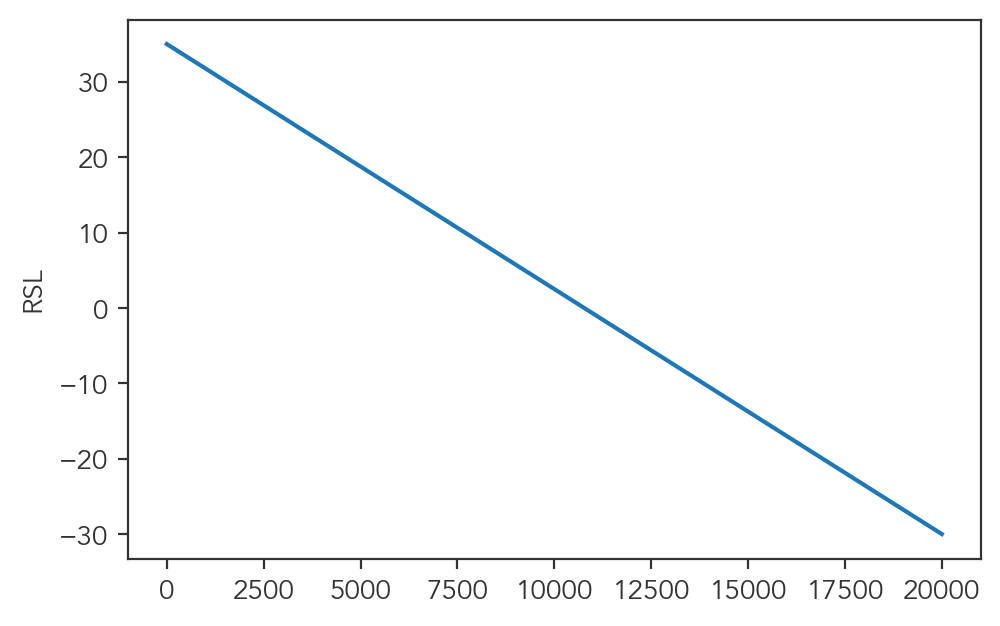

In [4]:
# sea level
#sl_fun = lambda t: jnp.ones_like(t)+35
#sl_fun1 = lambda t: 35*jnp.sin((t+23500)/8750)+20 # wanted a more distinct looking prograde
sl_fun_prog = lambda t: -0.00325*t+35 # even simpler distinct prograding with lower sea level

plt.plot(t,sl_fun_prog(t))
# plt.plot(t,sl_fun1(t))
# plt.plot(t,sl_fun2(t))

plt.ylabel('RSL')

## Define w: initial proxy composition
wi = jnp.ones_like(h)*sec_w_fun(t)[0] # first secular value value boundary condition
print(wi_m[0])

calculated ymin,ymax = -341.00, 140.00
mean grid dy = 4.815e-01


running model: progradational_A0.1_ylen1000_2026-07-13 16:34:   0%|          | 0/2000 [00:00<?, ? compiled ste…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


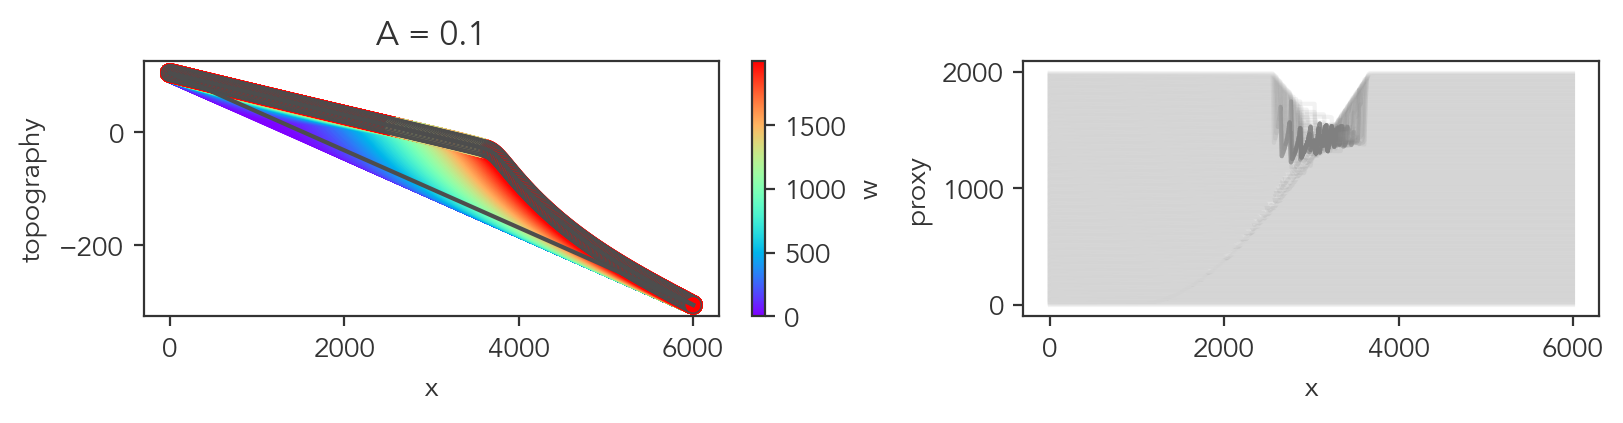

In [5]:
## name of model
desc = 'progradational' 

params['alg_coef'] = 5.5  # moved from run() kwarg -- alg_coef belongs in params, not run()

mod_prog = run(params,                           
          model_desc = desc,                 
          hi = h,                           
          wi = wi,                            
          wi_sec = True,                     
          sl_fun = sl_fun_prog,                   
          sec_w_fun = sec_w_fun,            
          depth_w_fun = None,        
          growth_fun_alg = algal_growth,    
          plot_skip = 10,
          const_K = False,
          w_set_erode = True,               
          full_storage = False,
          figsize=(8,2),
          normalize_balance=True)

### Facies scheme and diagnostics

`facies_data`/`facies_colours` define a simple depth-binned facies scheme
(shallow grainstone down to deep marine mudstone) used to color the gridded
stratigraphy in `plot_grids()`. The **same** scheme (built here once, from the
progradational run's max depth) is reused for all three scenarios below so
the three are directly comparable.

`mass_balance()` and `im_res_compare()` are `Model_output`'s built-in
diagnostics: the former checks the model's mass/proxy bookkeeping against an
analytical expectation, the latter checks how sensitive the gridded-image
outputs are to the chosen vertical grid resolution (`ylen`).

max depth = 411.00


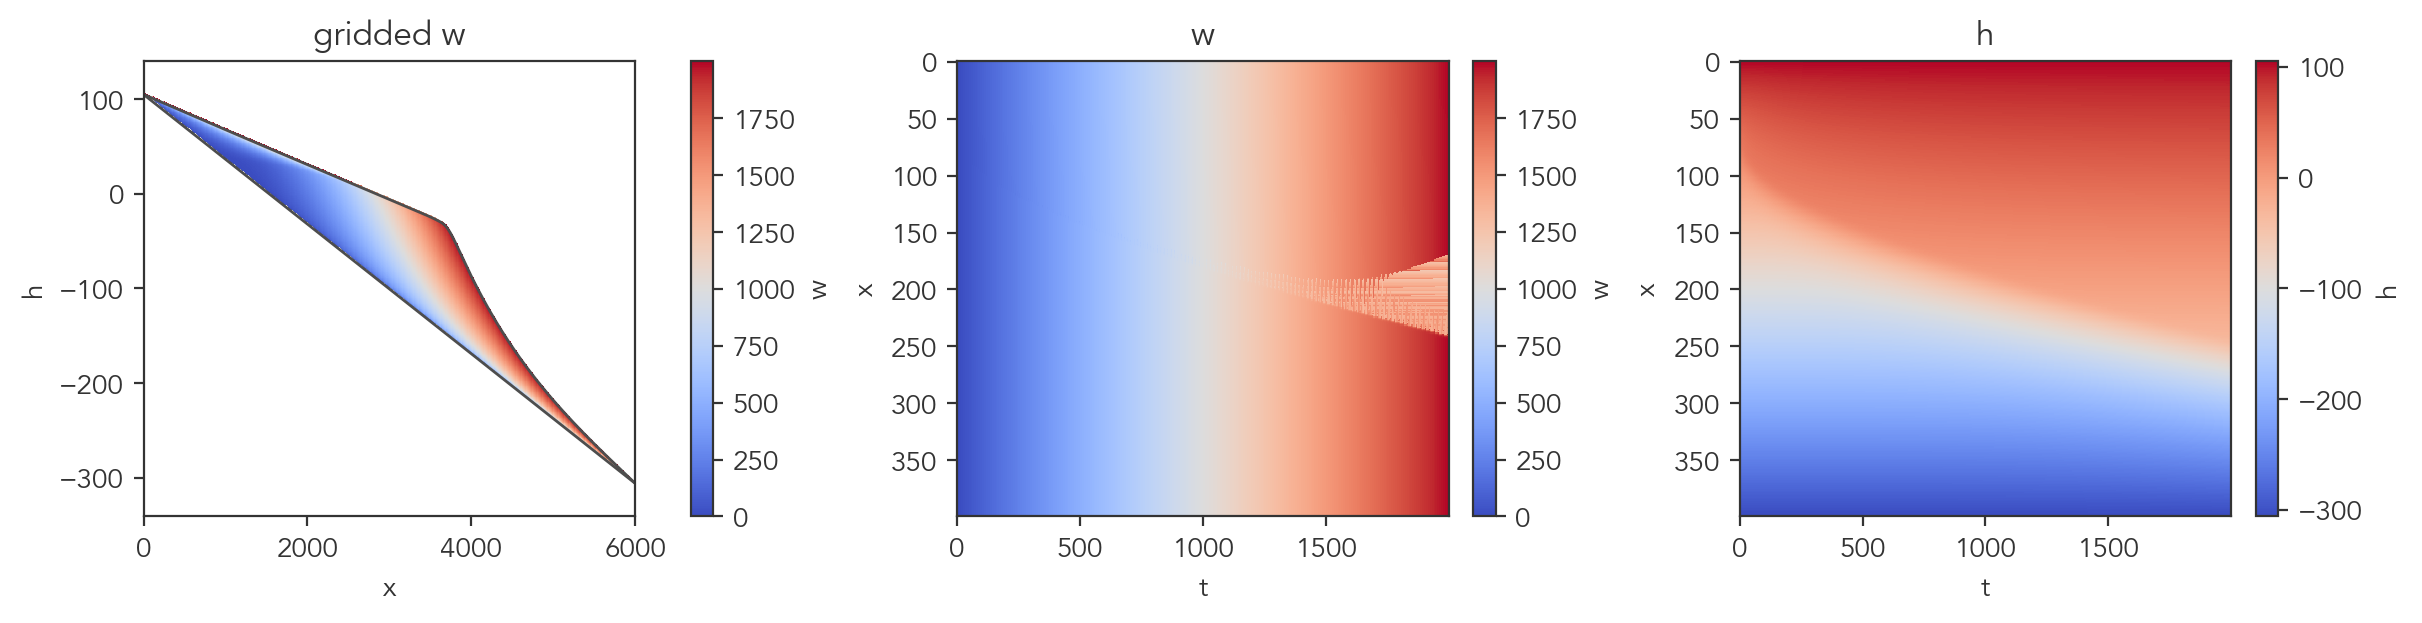

In [6]:
# define max depth
max_depth = np.nanmax(mod_prog['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
facies_data = [{'name':'Terrestrial','type': 'land','width':1,'min':1,'max':2}, # terrestrial is always everyting <0 (above water)
               {'name':'Grainstone','type': 'uniform', 'min': -0.01, 'max': max_depth/20,'width':.8}, # need this slightly modified min and the threshold below to make it work well
               {'name':'Packstone','type': 'uniform', 'min': max_depth/20, 'max': max_depth/15,'width':.6},
               {'name':'Wackestone','type': 'uniform', 'min': max_depth/15, 'max': max_depth/12,'width':.4},
               {'name':'Mudstone','type': 'uniform', 'min': max_depth/12, 'max': max_depth/10,'width':.3},
               {'name':'Shallow Marine','type': 'uniform', 'min': max_depth/10, 'max': max_depth/8,'width':.3},
               {'name':'Intermediate Marine','type': 'uniform', 'min': max_depth/8, 'max': max_depth/5,'width':.2},
               {'name':'Deep Marine','type': 'uniform', 'min': max_depth/5, 'max': max_depth,'width':.2}]


# facies colours # my_pal
facies_colours = list(sns.color_palette('BrBG',n_colors=len(facies_data)+1).as_hex()) # add one as going to drop the white one
facies_colours.pop(5) # drop the white one # was 4
sns.color_palette(facies_colours) # look at the palette

## model outputs
out_prog = Model_output(**mod_prog,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out_prog.plot_grids()

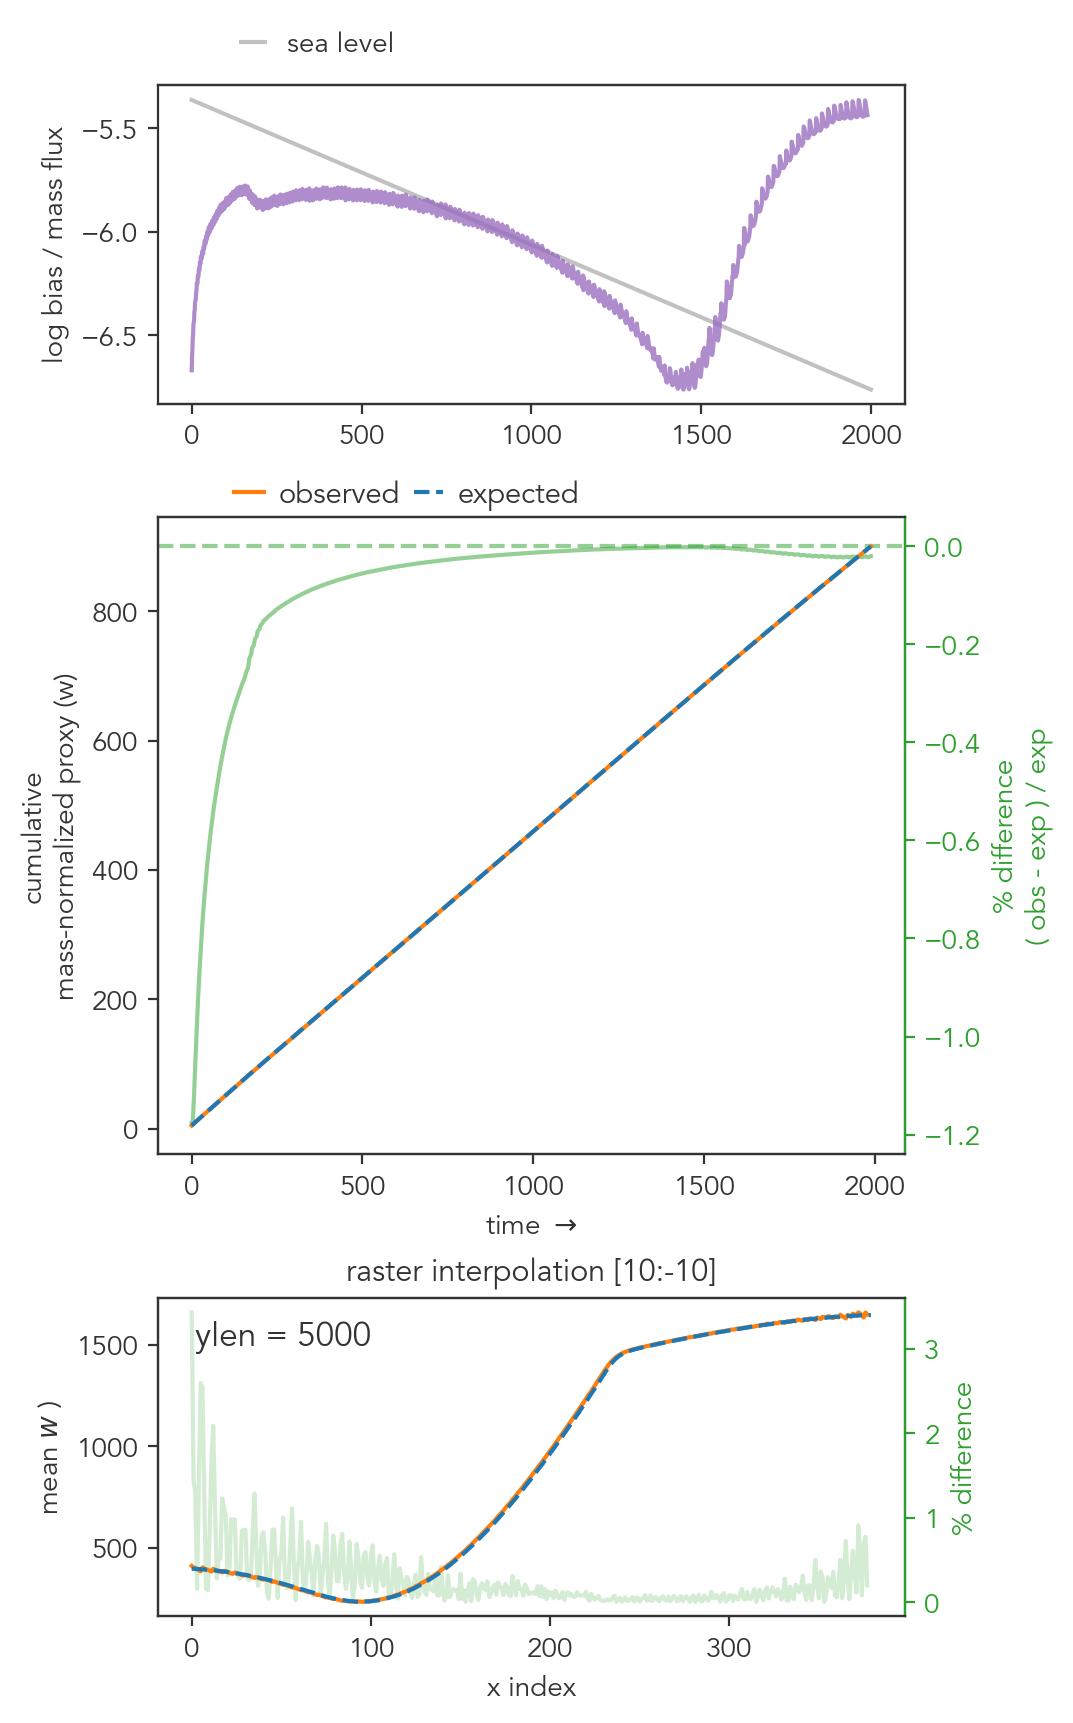

In [7]:
fig,ax,diff = out_prog.mass_balance(out=True,rsl=True,percent=True,show='proxy',start=10,im_l_lim=10,im_r_lim=-10)

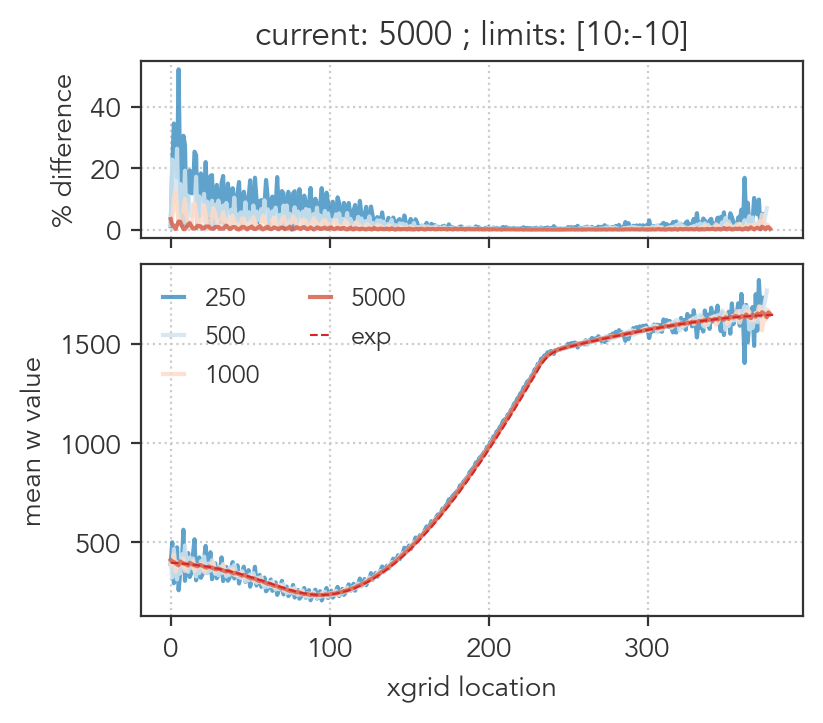

In [8]:
fig = out_prog.im_res_compare(pal='RdBu_r',ncols='multi',im_l_lim=10,im_r_lim=-10)

## Aggradational
A steeper growth function (less productive at very shallow depths) paired
with a repeating sawtooth relative-sea-level curve -- each cycle raises then
sharply drops accommodation, producing stacked, shoaling-upward parasequences
bounded by flooding surfaces, without much net lateral shoreline motion.

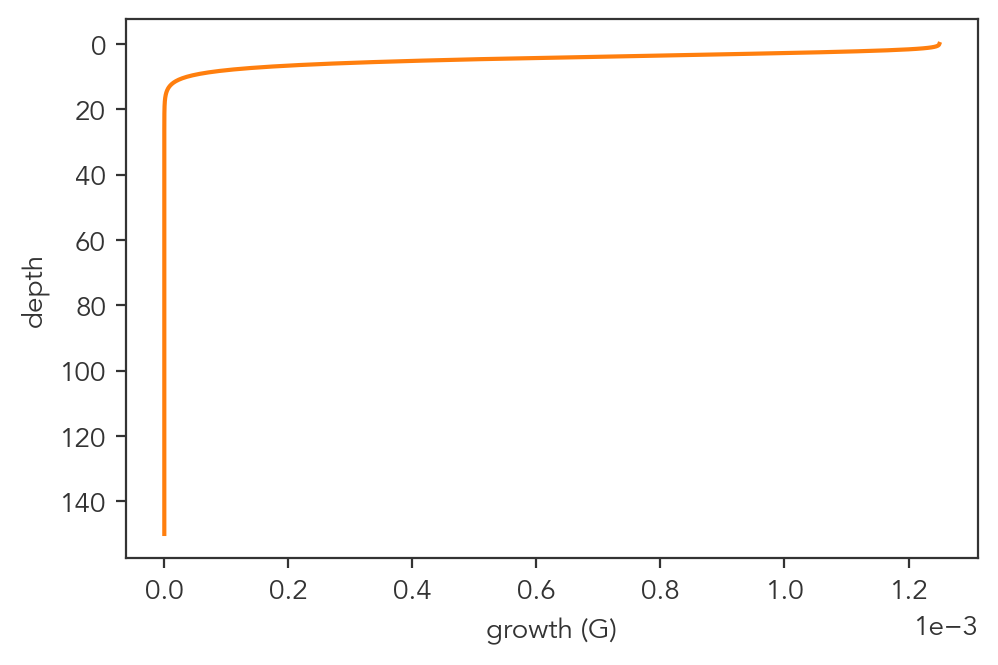

In [9]:
## Growth Functions ##
## dummy depth data
z = np.linspace(1e-5,150,1000)

Dt_alg = 0 #5 # maybe this is a solution for a lag parameter
algal_growth_agg = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=Dt_alg,k=0.5) # default k=0.1

# pelagic growth
plt.plot(algal_growth_agg(z),z,color='tab:orange',label='algal',ls='-')
plt.xlabel('growth (G)')
plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('depth')
plt.gca().invert_yaxis()

In [10]:
# sawtooth for stacking parasequences (this one works super well but ends up being unrealistic as instantaneous sl rise. also removes lazarus beds as instantaneous)
def ssawtooth(t,amplitude, period, rise, drop):
    sawtooth_wave = amplitude * (1 - (t % period) / period) + rise*t - drop
    return sawtooth_wave


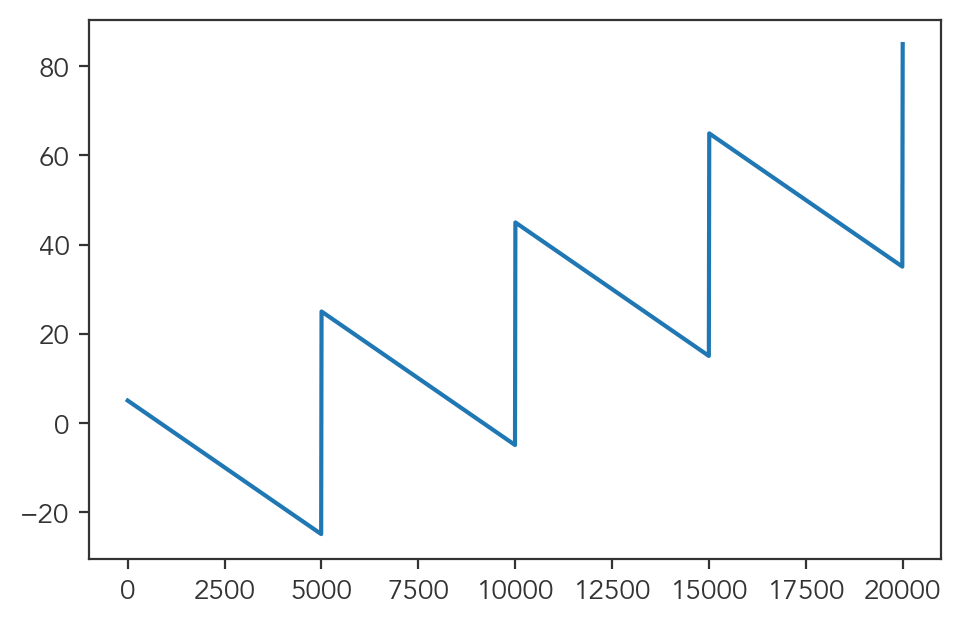

In [11]:
wave = ssawtooth(t,amplitude=50, period=2.5, rise=0.004, drop=45)
plt.plot(t,wave,label='saw')

# allow for use in jax jit 
sl_fun_saw = lambda i: jnp.interp(i,t,wave)

calculated ymin,ymax = -391.00, 190.00
mean grid dy = 5.816e-01


running model: aggradational_A0.1_ylen1000_2026-07-13 16:41:   0%|          | 0/2000 [00:00<?, ? compiled step…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


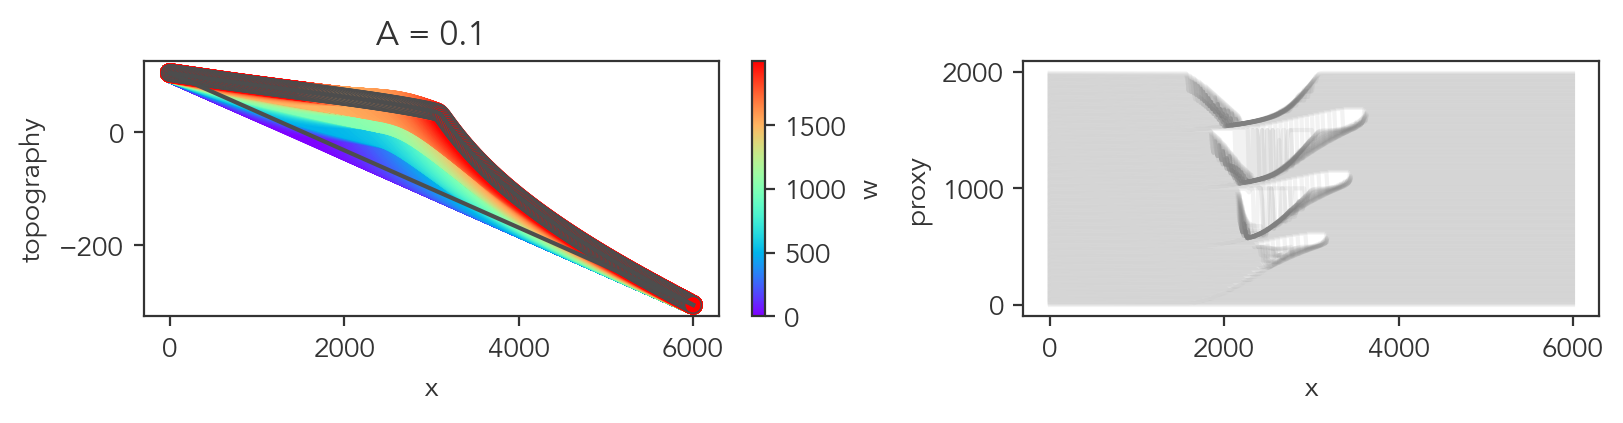

In [12]:
# name of model
desc = 'aggradational' 

params['alg_coef'] = 28.5  # moved from run() kwarg -- alg_coef belongs in params, not run()

mod_agg = run(params,                           
          model_desc = desc,                 
          hi = h,                           
          wi = wi,                            
          wi_sec = True,                     
          sl_fun = sl_fun_saw,                   
          sec_w_fun = sec_w_fun,            
          depth_w_fun = None,        
          growth_fun_alg = algal_growth_agg,    
          plot_skip = 10,                    
          w_set_erode = True,               
          full_storage = False,
          figsize=(8,2))

max depth = 411.00


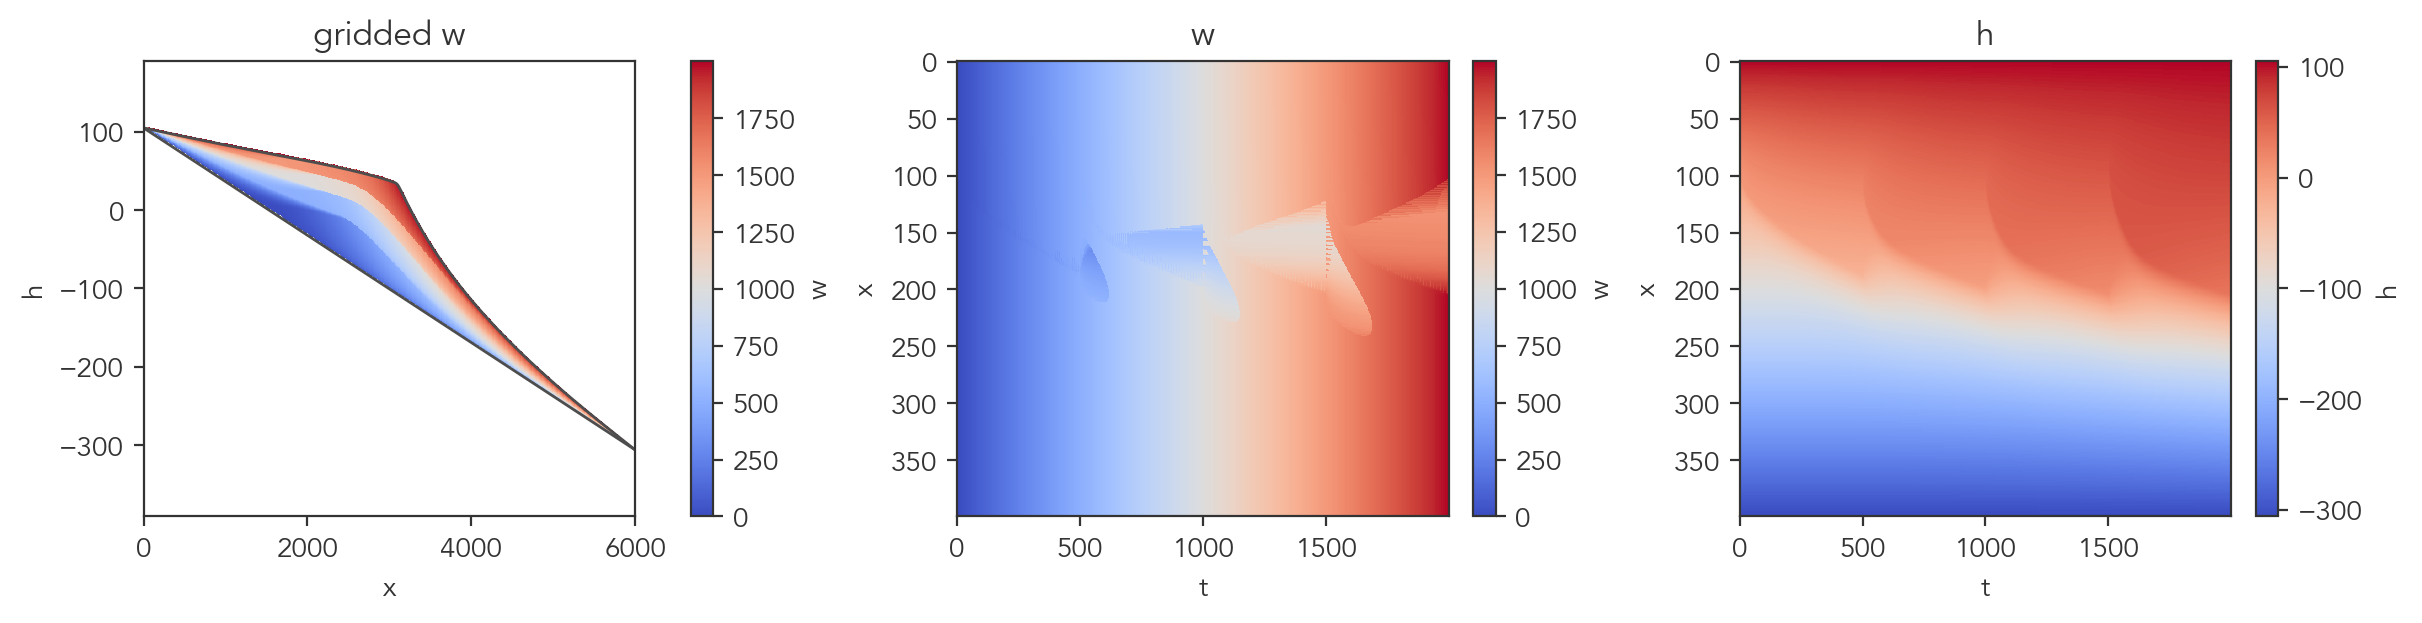

In [13]:
# define max depth
max_depth = np.nanmax(mod_agg['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
facies_data = [{'name':'Terrestrial','type': 'land','width':1,'min':1,'max':2}, # terrestrial is always everyting <0 (above water)
               {'name':'Grainstone','type': 'uniform', 'min': -0.01, 'max': max_depth/20,'width':.8}, # need this slightly modified min and the threshold below to make it work well
               {'name':'Packstone','type': 'uniform', 'min': max_depth/20, 'max': max_depth/15,'width':.6},
               {'name':'Wackestone','type': 'uniform', 'min': max_depth/15, 'max': max_depth/12,'width':.4},
               {'name':'Mudstone','type': 'uniform', 'min': max_depth/12, 'max': max_depth/10,'width':.3},
               {'name':'Shallow Marine','type': 'uniform', 'min': max_depth/10, 'max': max_depth/8,'width':.3},
               {'name':'Intermediate Marine','type': 'uniform', 'min': max_depth/8, 'max': max_depth/5,'width':.2},
               {'name':'Deep Marine','type': 'uniform', 'min': max_depth/5, 'max': max_depth,'width':.2}]

# facies colours # my_pal
facies_colours = list(sns.color_palette('BrBG',n_colors=len(facies_data)+1).as_hex()) # add one as going to drop the white one
facies_colours.pop(5) # drop the white one # was 4
sns.color_palette(facies_colours) # look at the palette

## model outputs
out_agg = Model_output(**mod_agg,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,tol=5,images=True)
out_agg.plot_grids()

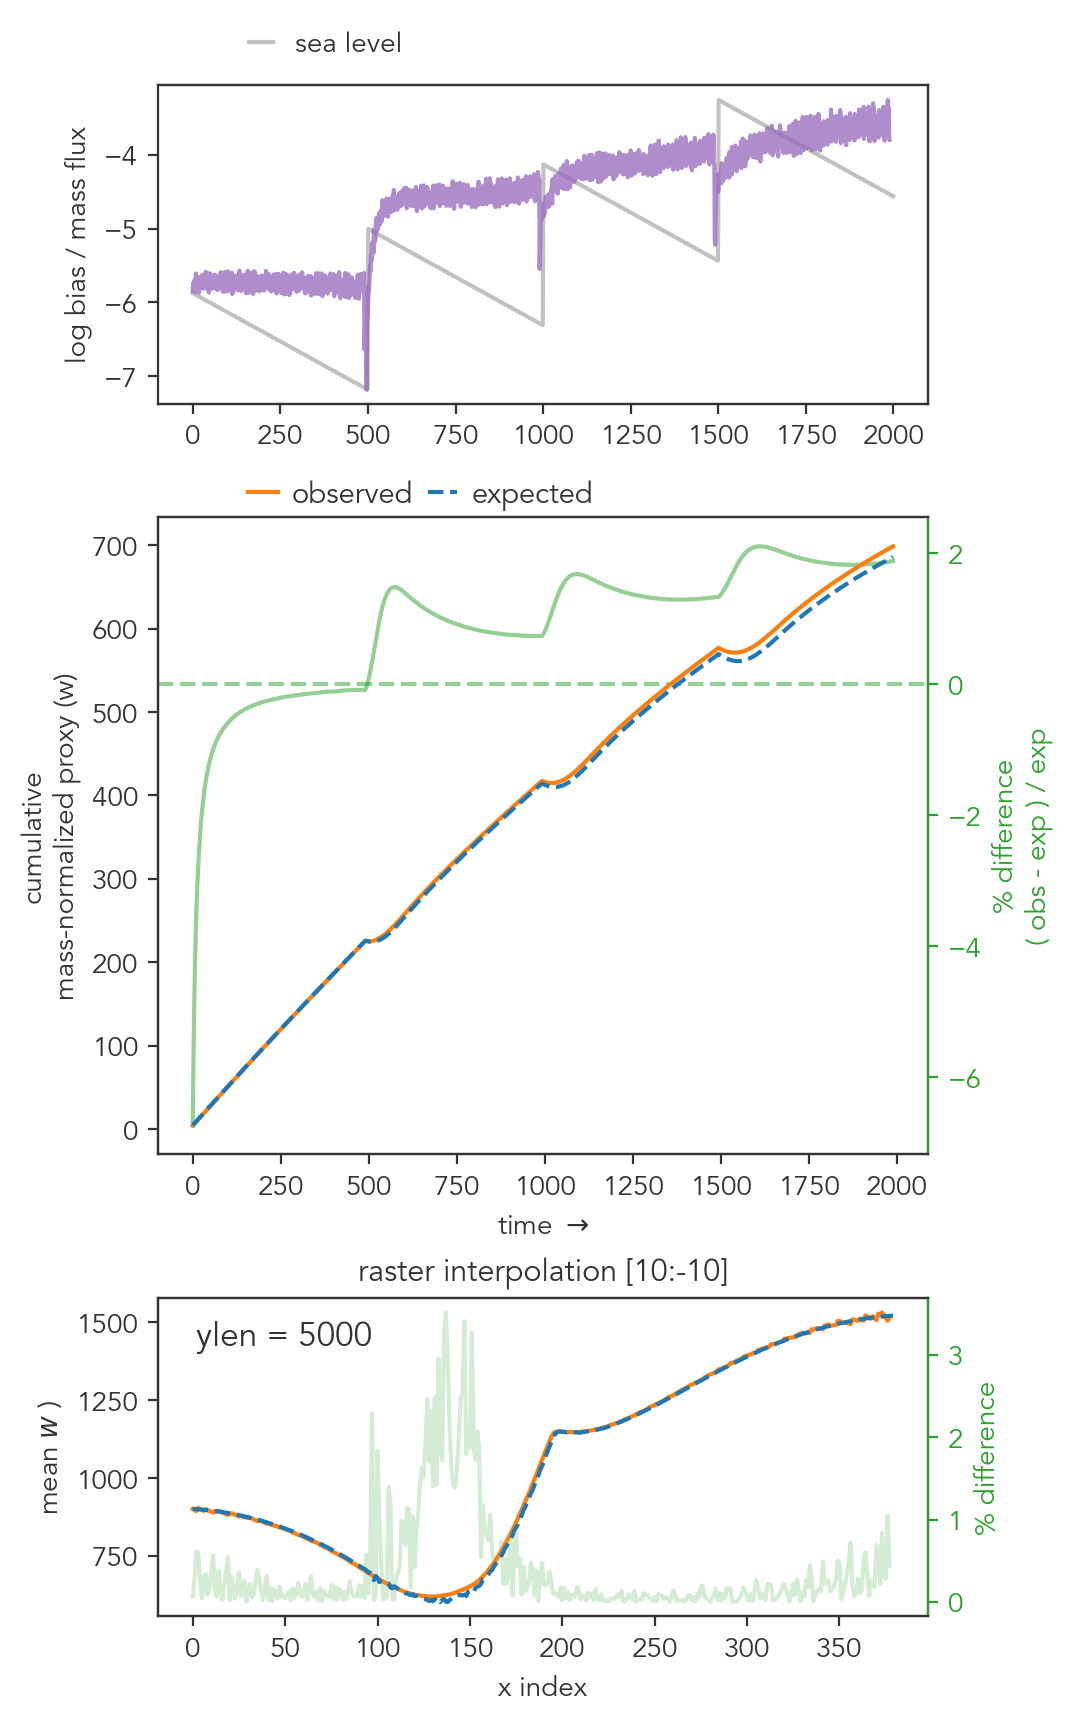

In [14]:
fig,ax,diff = out_agg.mass_balance(out=True,rsl=True,percent=True,show='proxy',start=10,im_l_lim=10,im_r_lim=-10)

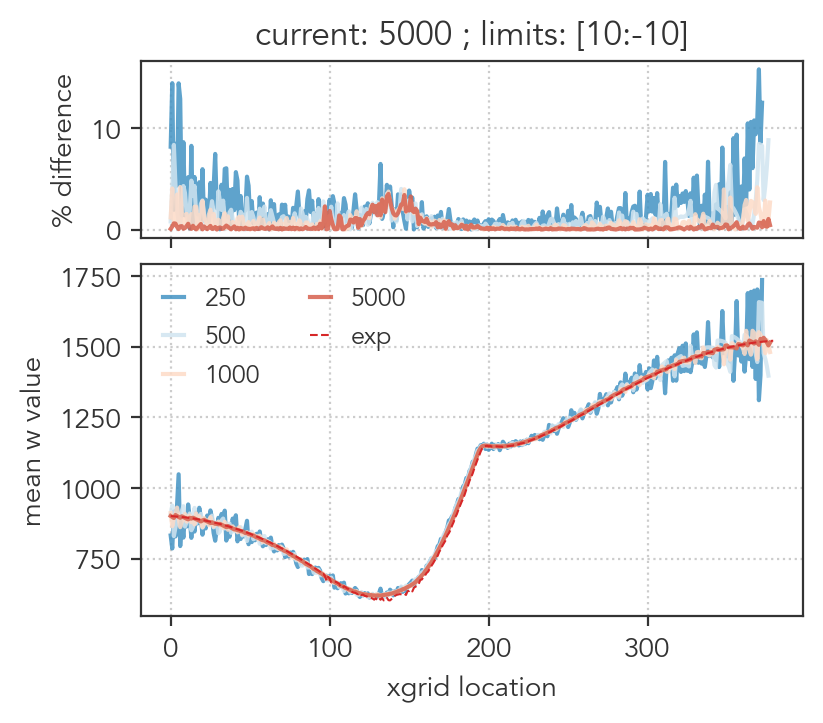

In [15]:
fig = out_agg.im_res_compare(pal='RdBu_r',ncols='multi',im_l_lim=10,im_r_lim=-10)

## Retrogradational
Relative sea level now rises steadily (accommodation outpaces supply, using
the same steep growth function as the aggradational run): the shoreline
steps landward and the platform backsteps/thins through time.

0.0


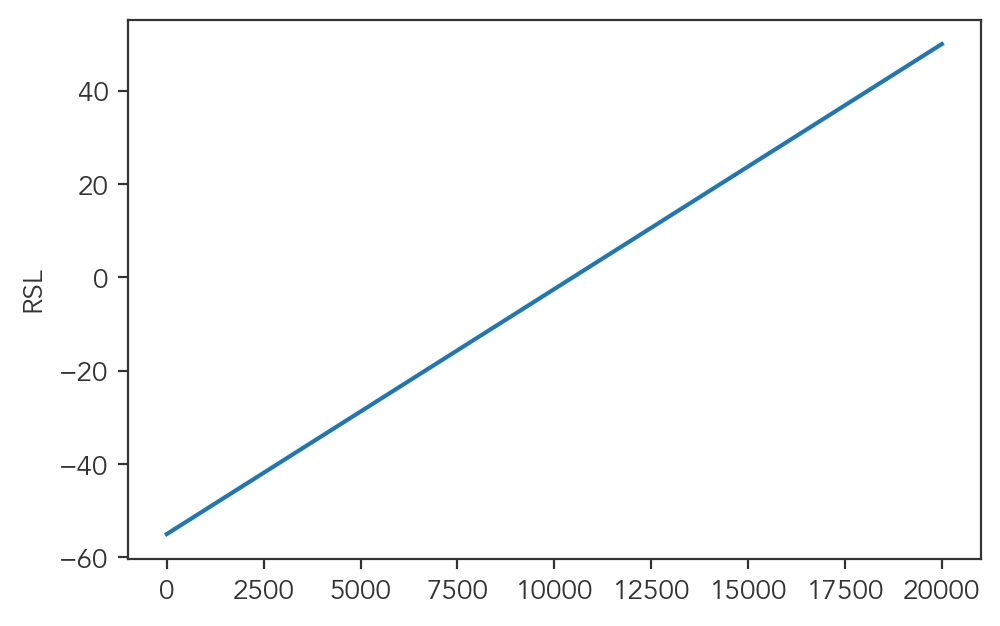

In [16]:
# sea level
sl_fun_reg = lambda t: 0.00525*t-55 # even simpler distinct prograding with lower sea level

plt.plot(t,sl_fun_reg(t))
# plt.plot(t,sl_fun1(t))
# plt.plot(t,sl_fun2(t))

plt.ylabel('RSL')

## Define w: initial proxy composition
wi = jnp.ones_like(h)*sec_w_fun(t)[0] # first secular value value boundary condition
print(wi_m[0])

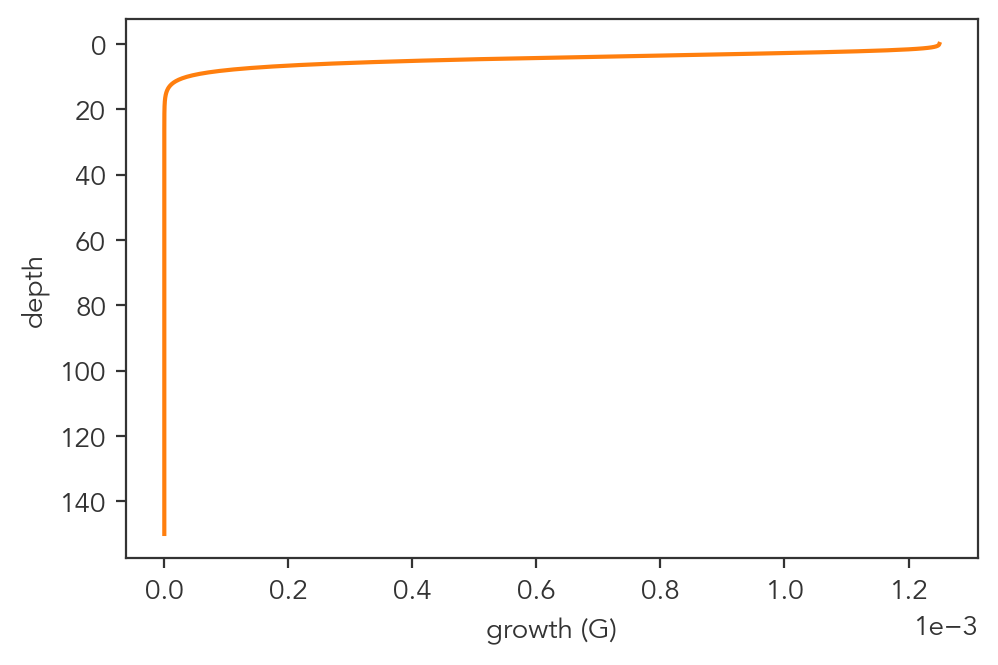

In [17]:
algal_growth_reg = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=Dt_alg,k=0.5) # default k=0.1

# pelagic growth
plt.plot(algal_growth_reg(z),z,color='tab:orange',label='algal',ls='-')
plt.xlabel('growth (G)')
plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.ylabel('depth')
plt.gca().invert_yaxis()

calculated ymin,ymax = -361.00, 160.00
mean grid dy = 5.215e-01


running model: retroradational_A0.1_ylen1000_2026-07-13 16:50:   0%|          | 0/2000 [00:00<?, ? compiled st…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


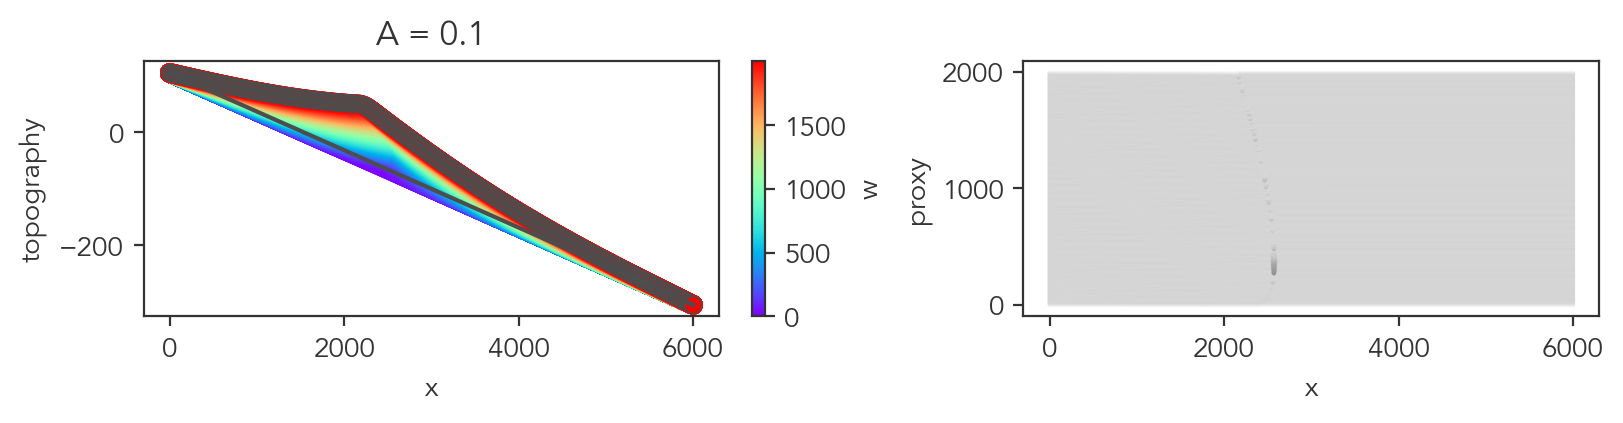

In [18]:
## name of model
desc = 'retroradational' 

params['alg_coef'] = 8.5  # moved from run() kwarg -- alg_coef belongs in params, not run()

mod_reg = run(params,                           
          model_desc = desc,                 
          hi = h,                           
          wi = wi,                            
          wi_sec = True,                     
          sl_fun = sl_fun_reg,                   
          sec_w_fun = sec_w_fun,            
          depth_w_fun = None,        
          growth_fun_alg = algal_growth_reg,    
          plot_skip = 10,                    
          w_set_erode = True,               
          full_storage = False,
          figsize=(8,2))

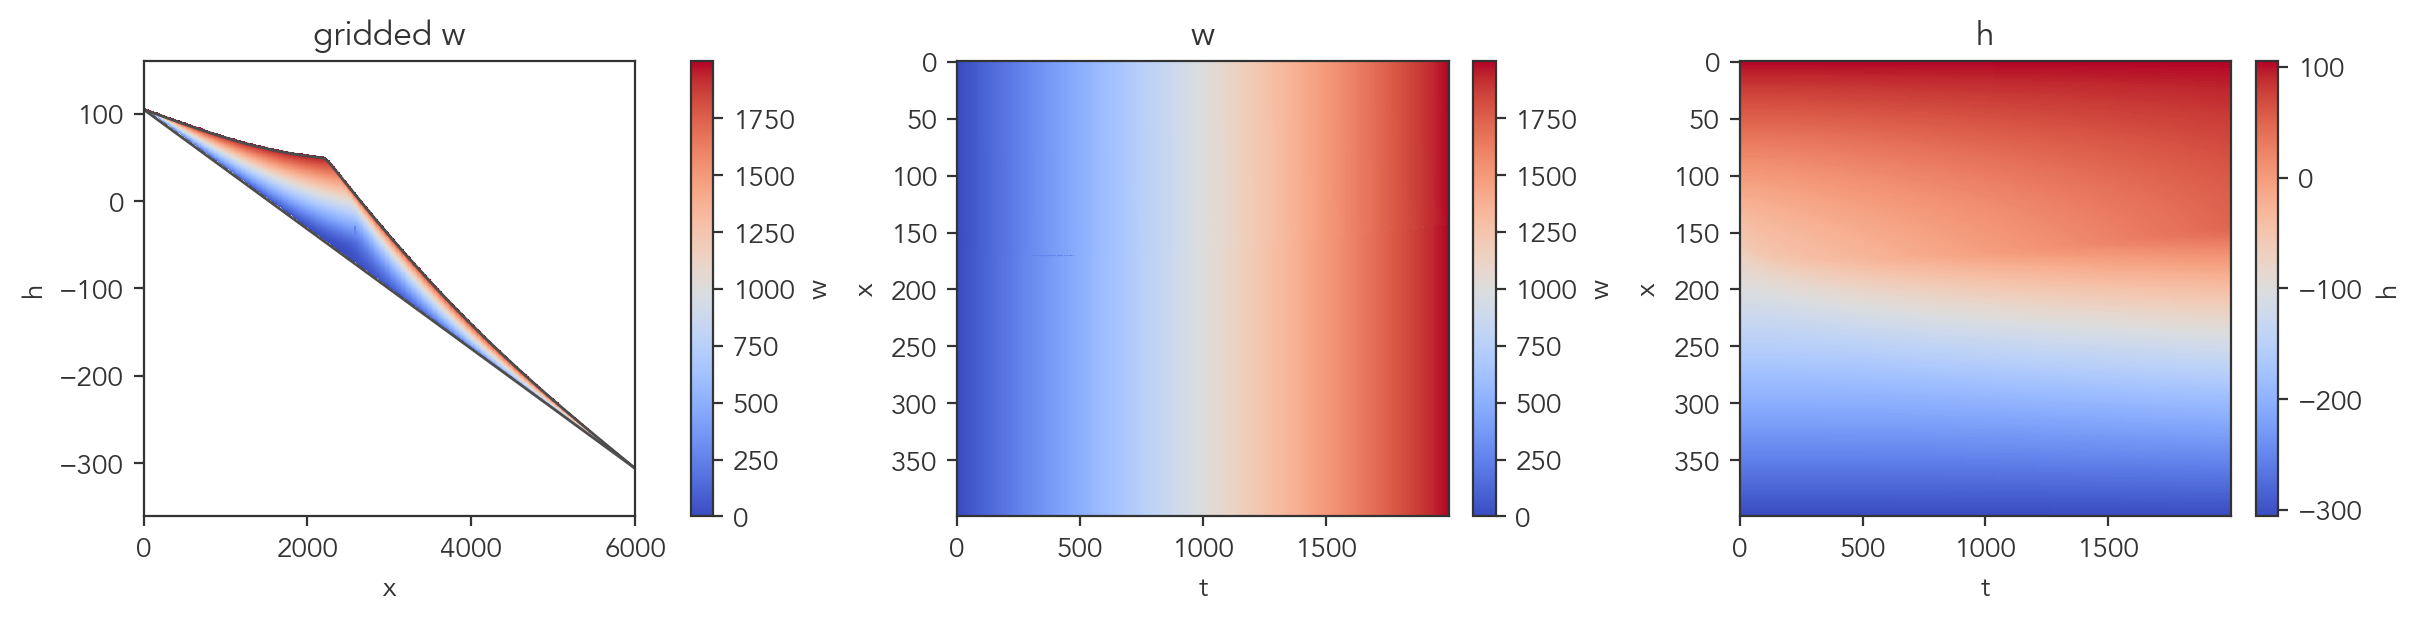

In [19]:
## model outputs
facies_data = [{'name':'Terrestrial','type': 'land','width':1,'min':1,'max':2}, # terrestrial is always everyting <0 (above water)
               {'name':'Grainstone','type': 'uniform', 'min': -0.01, 'max': max_depth/20,'width':.8}, # need this slightly modified min and the threshold below to make it work well
               {'name':'Packstone','type': 'uniform', 'min': max_depth/20, 'max': max_depth/15,'width':.6},
               {'name':'Wackestone','type': 'uniform', 'min': max_depth/15, 'max': max_depth/12,'width':.4},
               {'name':'Mudstone','type': 'uniform', 'min': max_depth/12, 'max': max_depth/10,'width':.3},
               {'name':'Shallow Marine','type': 'uniform', 'min': max_depth/10, 'max': max_depth/8,'width':.3},
               {'name':'Intermediate Marine','type': 'uniform', 'min': max_depth/8, 'max': max_depth/5,'width':.2},
               {'name':'Deep Marine','type': 'uniform', 'min': max_depth/5, 'max': max_depth,'width':.2}]

out_reg = Model_output(**mod_reg,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out_reg.plot_grids()

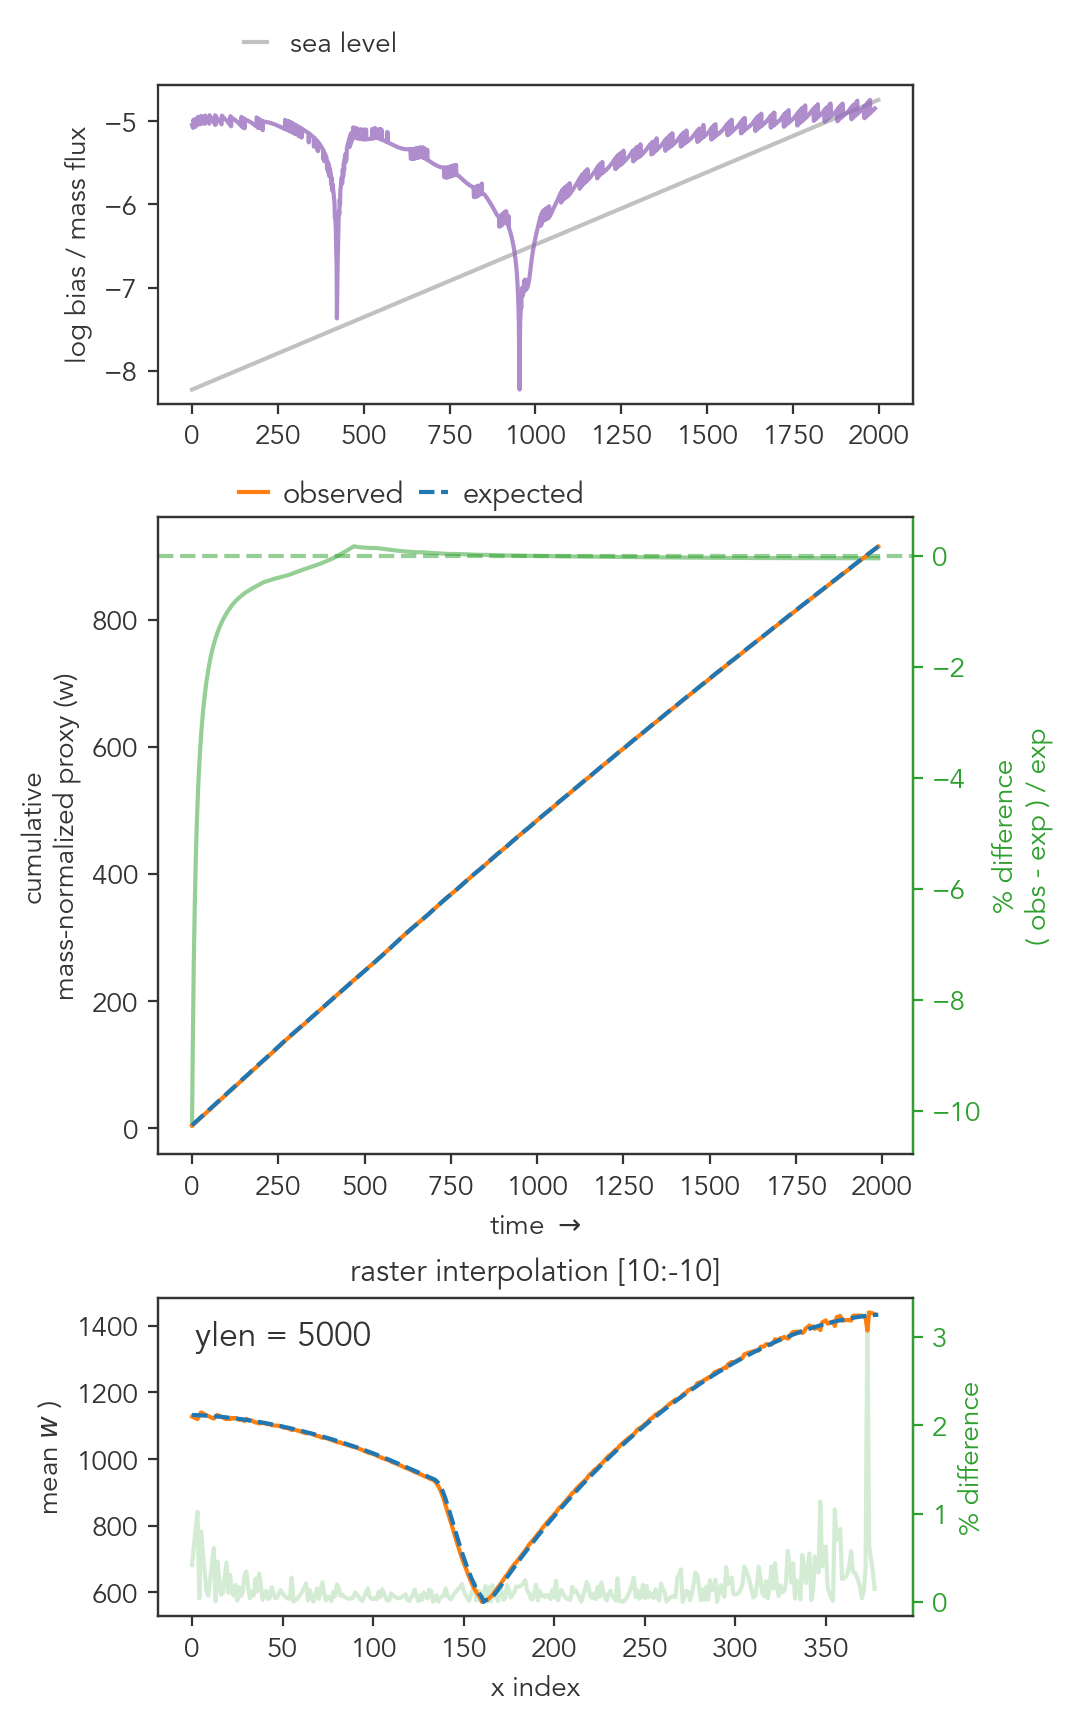

In [20]:
fig,ax,diff = out_reg.mass_balance(out=True,rsl=True,percent=True,show='proxy',start=10,im_l_lim=10,im_r_lim=-10)

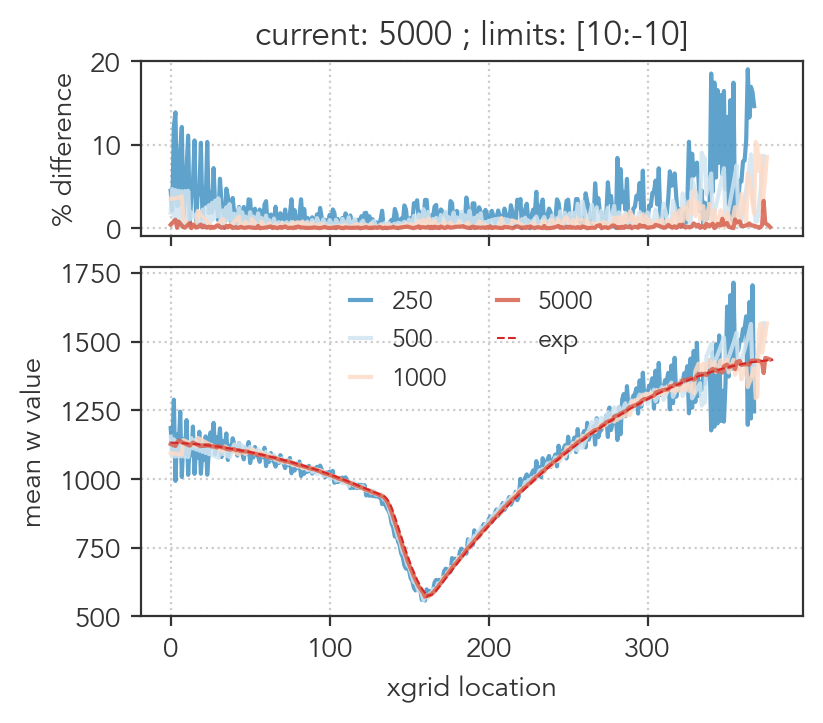

In [21]:
fig = out_reg.im_res_compare(pal='RdBu_r',ncols='multi',im_l_lim=10,im_r_lim=-10)

## Side-by-side comparison

Putting all three runs together: gridded proxy cross-sections (top), a
measured stratigraphic column at the same fixed location in each (middle),
and an inset relative-sea-level curve for each (bottom of each panel). This
is the same kind of figure used to compare stacking patterns in the
associated paper.

[Text(0.0, 0, '2000'), Text(1000.0, 0, '1000'), Text(2000.0, 0, '0')]

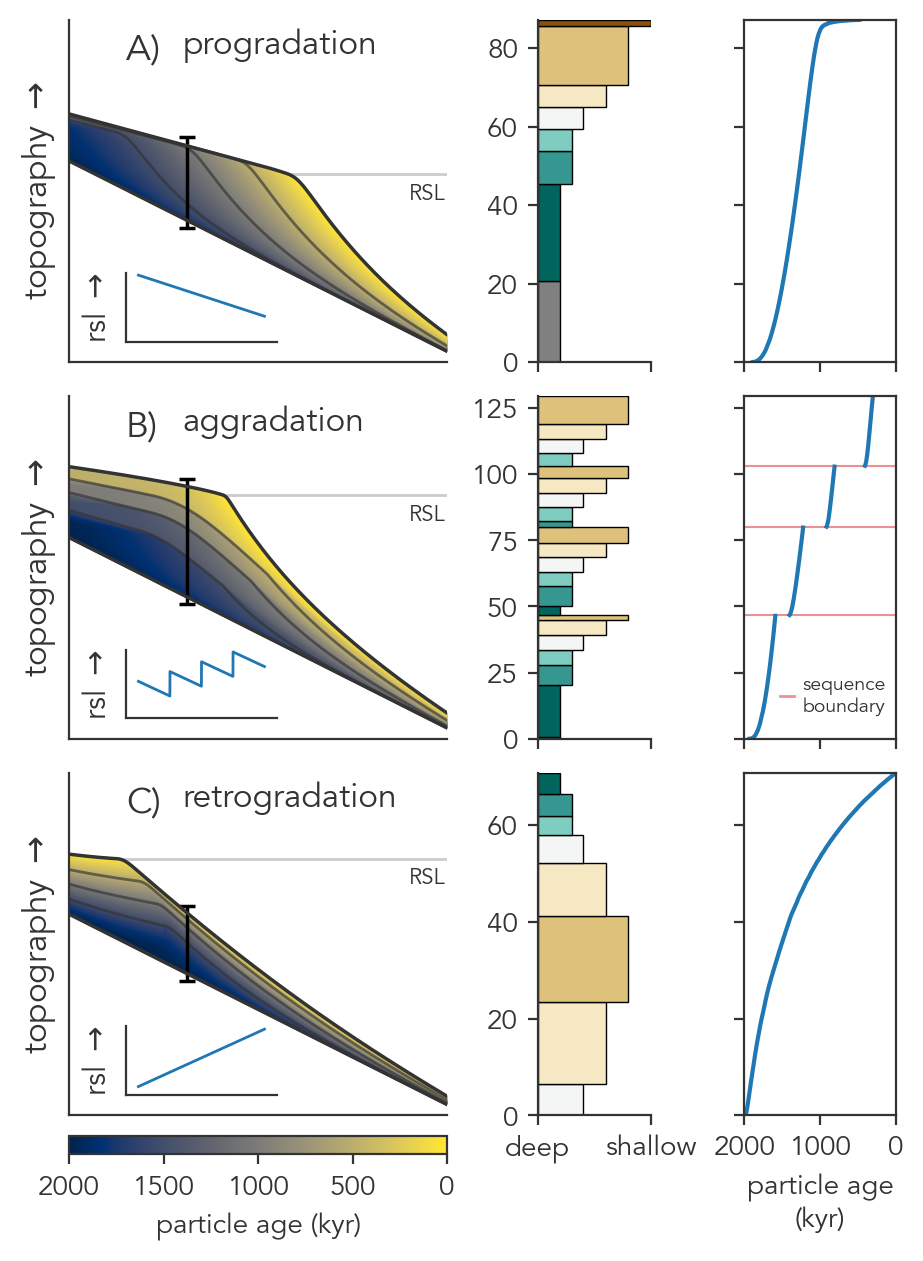

In [22]:
fig,ax = plt.subplot_mosaic(
    """
    adg
    beh
    cfi
    """, figsize=(4.5,6.25),layout='constrained',sharey=False,sharex=False,width_ratios=[1,.3,.4],height_ratios=[1,1,1]) # [1,.3,.4] figsize=(11,6) 4.5,6.2

axs = sorted(ax.keys())
# set colormap
cmap ='cividis'

## progradational ##
sm = ax['a'].imshow(out_prog.im_w,aspect='auto',extent=out_prog.extent,origin='lower',cmap=cmap,rasterized=True)
ax['a'].plot(mod_prog['x'],mod_prog['beds_eroded'][-1],color='.2',zorder=1000,lw=1.25)
ax['a'].plot(mod_prog['x'],mod_prog['beds_eroded'][0],color='.2',zorder=1000,lw=1.25)

## aggradational ##
sm = ax['b'].imshow(out_agg.im_w,aspect='auto',extent=out_agg.extent,origin='lower',cmap=cmap,rasterized=True)
ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][-1],color='.2',zorder=1000,lw=1.25)
ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][0],color='.2',zorder=1000,lw=1.25)
# surfaces 
# ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][out_agg.reg_idx,:].T,color='.2',alpha=1,ls='--',lw=1.125,zorder=10000,label='regressive surface');
# ax['b'].plot(mod_agg['x'],mod_agg['beds_eroded'][out_agg.tran_idx,:].T,color='.2',alpha=1,ls=':',lw=1.125,zorder=10000,label='transgressive surface');

## retrogradational ##
sm = ax['c'].imshow(out_reg.im_w,aspect='auto',extent=out_reg.extent,origin='lower',cmap=cmap,rasterized=True)
ax['c'].plot(mod_reg['x'],mod_reg['beds_eroded'][-1],color='.2',zorder=1000,lw=1.25)
ax['c'].plot(mod_reg['x'],mod_reg['beds_eroded'][0],color='.2',zorder=1000,lw=1.25)

# colorbar
cbar = plt.colorbar(sm,ax=ax['c'],orientation='horizontal',label='particle age (kyr)',pad=-0.275)
# reverse the tick labels so it is intuitive for stratigraphic age
ticks = cbar.get_ticks()
cbar.set_ticks(ticks)  # Set original ticks
cbar.set_ticklabels([int(i) for i in ticks[::-1]])  # Reverse the tick labels

# add colours to time beds
for idx,m in enumerate([mod_prog,mod_agg,mod_reg]):
    b = m['beds_eroded']
    skip = 500
    end = b.shape[0]
    #ax[axs[idx]].set_prop_cycle(cycler('color',sns.color_palette('Greys',n_colors=int(np.ceil(end/skip)))))
    for i in range(end):
        if i%skip==0:
            ax[axs[idx]].plot(m['x'],b[i],alpha=0.65,lw=1,color='.2')
            
# format
[ax[axs[a]].set_xlim(1750,5000) for a in range(3)]
[ax[axs[a]].set_ylim(-250,150) for a in range(3)]

labs = ['progradation','aggradation','retrogradation']
for a,l in zip(range(3),labs):
    a = axs[a]
    ax[a].spines[['right','top']].set_visible(False)
    ax[a].set_xticks([])
    ax[a].set_yticks([])
    ax[a].text(0.3,0.9,l,transform=ax[a].transAxes,fontsize=12,ha='left')
    ax[a].set_ylabel(r'topography $\rightarrow$',fontsize=12)
#ax['c'].set_xlabel(r'distance $\rightarrow$',fontsize=12)

## stratigraphy ##
lidx = 2760
skip = 6

# progradation
locs = out_prog.Nx_toX(lidx,out='Nx')
targ_val_prog,new_y_val_prog,y_min,y_max,seq_y_prog = out_prog.strat_col_im(locs,targ=out_prog.im_w,out=True,plot=True,ax=ax['d'],
                                                                x_axis=True,seq_bounds=False,seq_color='tab:red',seq_lw=1)
ax['g'].plot(targ_val_prog,new_y_val_prog)#[::skip],'.',ms=3)
ax['g'].sharey(ax['d'])

# aggradation
locs = out_agg.Nx_toX(lidx,out='Nx')
targ_val_agg,new_y_val_agg,y_min,y_max,seq_y_agg = out_agg.strat_col_im(locs,targ=out_agg.im_w,out=True,plot=True,ax=ax['e'],
                                                                x_axis=True,seq_bounds=True,seq_color='tab:red',seq_lw=1)
# make discontinuous
val = targ_val_agg
grad = np.gradient(val)
mg = np.mean(grad)
vidx = np.where(grad>20*mg,np.nan,val) # find steepest jumps and chop

ax['h'].plot(vidx,new_y_val_agg) #[::skip],'.',ms=3)
ax['h'].sharey(ax['e'])
for j in seq_y_agg[1::2]:
    ax['h'].axhline(j,color='tab:red',ls='-',lw=0.75,alpha=0.5,label='sequence boundary',zorder=0)

# retrogradation
locs = out_reg.Nx_toX(lidx,out='Nx')
targ_val_reg,new_y_val_reg,y_min,y_max,seq_y_reg = out_reg.strat_col_im(locs,targ=out_reg.im_w,out=True,plot=True,ax=ax['f'],
                                                                x_axis=True,seq_bounds=False,seq_color='tab:red',seq_lw=1)

ax['i'].plot(targ_val_reg,new_y_val_reg)#[::skip],'.',ms=3)
ax['i'].sharey(ax['f'])

# format
#[ax[axs[a]].set_yticks([]) for a in range(3,6)]
ax['f'].sharex(ax['d'])
ax['e'].sharex(ax['d'])
ax['i'].sharex(ax['g'])
ax['h'].sharex(ax['g'])
[ax[a].set_xlabel(None) for a in ['d','e']]
ax['i'].set_xlabel('particle age\n(kyr)')
ax['i'].tick_params(axis='x', labelsize=10)  # change the font size of x tick labels to 12
#[ax[axs[a]].spines[['right','top','left']].set_visible(False) for a in range(6,9)]
ax['g'].set_xlim(0,2000)
ax['g'].set_xticks(np.linspace(0,2000,3));

# label sections
sbar(ax=ax['a'],x_value=lidx,ymin=-93,ymax=13,lw=1.25,capsize=3,color='k',zorder=100)
sbar(ax=ax['b'],x_value=lidx,ymin=-93,ymax=53,lw=1.25,capsize=3,color='k',zorder=100)
sbar(ax=ax['c'],x_value=lidx,ymin=-93,ymax=-5,lw=1.25,capsize=3,color='k',zorder=100)

# format
ax['f'].set_xlabel(None)
ax['f'].set_xticks([0,1],['deep','shallow'],fontsize=10)
[ax[a].tick_params(axis='x', which='both', bottom=True, labelbottom=False) for a in ['d','e']]
[ax[a].tick_params(axis='x', which='both', bottom=True, labelbottom=False) for a in ['g','h']]
ax['f'].set_xlim(0,1)
[ax[axs[a]].tick_params(axis='y', which='both', left=True, labelleft=False) for a in range(6,9)]

# add insets
for a,(m,o) in enumerate(zip([mod_prog,mod_agg,mod_reg],[out_prog,out_agg,out_reg])):
    axi = ax[axs[a]].inset_axes([0.15,0.06,0.4,0.2])
    axi.set_xticks([])
    axi.set_yticks([])
    axi.plot(t,m['rsl_strat'],lw=1) # '.8'
    axi.spines[['right','top']].set_visible(False)
    axi.set_ylabel(r'rsl $\rightarrow$',fontsize=11)
    axi.set_xlim(left=-2000,right=22000)
    axi.set_ylim(bottom=-70)
    # add sea level lines
    lx = o.shore_x(1999)
    rsl = m['rsl_strat'][-1]
    transform = blended_transform_factory(ax[axs[a]].transAxes, ax[axs[a]].transData)
    ax[axs[a]].hlines(rsl,xmin=lx,xmax=6000,color='.8',lw=1,zorder=0)
    ax[axs[a]].text(0.9,rsl-30,'RSL',fontsize=8,transform=transform)

# legend
# el = [Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls='--',alpha=1,label='regressive surface',markerfacecolor='none', markersize=0),
#       Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls=':',alpha=1,label='transgressive surface',markerfacecolor='none', markersize=0)]
el = [Line2D([0], [0],mew=0.65,lw=1, marker='v', color='tab:red', ls='-',alpha=0.5,label='sequence\nboundary',markerfacecolor='none', markersize=0)]
# using fig.legend as doesn't mess up spacing
leg = ax['h'].legend(handles=el,loc=1,bbox_to_anchor=(1.05,0.235),ncols=1,frameon=False,framealpha=1,fontsize=7,handletextpad=0.4,markerfirst=True,handlelength=0.75)

# label abc
# label
abc = [i+')' for i in string.ascii_uppercase[:3]]
bbox_props = dict(boxstyle='square,pad=0.1',edgecolor='k',facecolor='none',alpha=0.5)
for label, axis in zip(abc,axs):
    ax[axis].text(0.15,0.91,label,transform=ax[axis].transAxes,fontsize=13,ha='left',va='center')

# reverse x axis ticks
ticks = ax['i'].get_xticks()
ax['i'].set_xticks(ticks)  # Set original ticks
ax['i'].set_xticklabels([int(i) for i in ticks[::-1]])  # Reverse the tick labels

# save figure
